# Recover simulated Gaia astrometric orbits with JAXoplanet + NumPyro

This notebook loads one simulated system directly from `simulated_astrometry.h5` and fits the **same data** with 0-, 1-, and 2-planet models. The along-scan convention, Gaia reference epoch, and stellar-reflex calculation match `sim_astrometry.ipynb`.

The five standard astrometric parameters are initialized by weighted least squares. Injected orbital truth is optional and is used only to initialize NUTS and annotate plots; it is never used in the likelihood. The likelihood includes a fitted error-scale because the simulation draws scatter from `sigma_UEVA` but writes `sigma_reported` to `centroid_pos_error_al`.

In [1]:
from pathlib import Path
import warnings

import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_value
from numpyro.infer.util import log_likelihood
from jaxoplanet.orbits.keplerian import Central, System

jax.config.update("jax_enable_x64", True)
print("JAX devices:", jax.devices())
print("NumPyro version:", numpyro.__version__)

JAX devices: [CpuDevice(id=0)]
NumPyro version: 0.16.1


/Users/daniel/opt/anaconda3/envs/epochalypse-arm64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Change `DATASET_POPULATION` to test recovery on a different injected population. Each selected dataset is still fit with all entries in `MODEL_ORDERS`. Start with the quick settings, then increase the chain lengths for scientific conclusions.

## Recommended SNR-Filtered Systems

Re-identified after the simulated-data rerun (previous indices no longer match the current `simulated_astrometry.h5`). Selection criteria: large astrometric signature $\alpha = (M_p/M_\star)\,a\,\varpi$, and orbital period well within the ~5.3 yr observing baseline for good phase coverage.

### Single-Planet System

- `DATASET_POPULATION = "1planet_snrfilter"`
- `SYSTEM_INDEX = 10561`
- Mass: 78.0 Mjup
- Period: 2.64 years
- Astrometric signature: ≈239 mas

### Two-Planet System

- `DATASET_POPULATION = "2planet_snrfilter"`
- `SYSTEM_INDEX = 7728`

#### Planet 1

- Mass: 79.6 Mjup
- Period: 3.36 years
- Astrometric signature: ≈13.2 mas

#### Planet 2

- Mass: 68.3 Mjup
- Period: 5.18 years
- Astrometric signature: ≈14.9 mas

In [8]:
DATA_ROOT = Path("outputs/data")
HDF5_PATH = DATA_ROOT / "simulated_astrometry.h5"
DATASET_POPULATION = "2planet_snrfilter"  # 0planet, 1planet_nosnrfilter, etc.
SYSTEM_INDEX = 7728
MODEL_ORDERS = (0, 1, 2)

USE_INJECTED_INIT = True  # recovery test; set False for a blind search
NUM_WARMUP = 500
NUM_SAMPLES = 500
NUM_CHAINS = 2
RNG_SEED = 2026
TARGET_ACCEPT = 0.9

PERIOD_MIN_YEARS = 0.1
PERIOD_MAX_YEARS = 5000.0
GAIA_EPOCH_TCB_JD = 2457936.875
RSUN_TO_AU = 0.00465047
MJUP_TO_MSUN = 0.000954588
MARS_TO_MSUN = 0.107 * 3.0034896e-6
MAX_COMPANION_MASS_MSUN = 80.0 * MJUP_TO_MSUN

In [9]:
def load_simulated_system(population, system_index, hdf5_path=HDF5_PATH):
    system_id = f"{population}_SYS_{system_index:07d}"
    hdf5_path = Path(hdf5_path)
    if not hdf5_path.exists():
        raise FileNotFoundError(f"Missing simulated-data HDF5 file: {hdf5_path}")

    with pd.HDFStore(hdf5_path, mode="r") as store:
        manifest = store["manifest"]
        manifest_match = manifest.loc[manifest["population"] == population]
        if len(manifest_match) != 1:
            raise ValueError(
                f"Expected one manifest row for population={population!r}; "
                f"found {len(manifest_match)}"
            )
        hdf_key = manifest_match.iloc[0]["hdf_key"]
        if hdf_key not in store.keys():
            raise KeyError(f"Manifest points to missing HDF5 key: {hdf_key}")

        epochs = store.select(hdf_key, where=f"system_id == {system_id!r}")
        truth_table = store["injected_solutions"]

    if epochs.empty:
        raise KeyError(f"No epoch data found for {system_id} under {hdf_key}")
    epochs = epochs.sort_values("obs_time_tcb").reset_index(drop=True)

    required = {
        "obs_time_tcb", "centroid_pos_al", "centroid_pos_error_al",
        "parallax_factor_al", "scan_pos_angle",
        "gaia_source_id", "source_id_dr2",
    }
    missing = required.difference(epochs.columns)
    if missing:
        raise ValueError(f"{hdf_key} is missing columns: {sorted(missing)}")

    gaia_id = epochs["gaia_source_id"].iloc[0]
    dr2_id = epochs["source_id_dr2"].iloc[0]
    if epochs[["gaia_source_id", "source_id_dr2"]].drop_duplicates().shape[0] != 1:
        raise ValueError("Selected HDF5 epochs contain more than one source-key pair")

    match = truth_table.loc[truth_table["system_id"] == system_id]
    if len(match) != 1:
        raise ValueError(
            f"Expected one injected-solution row for {system_id}; found {len(match)}"
        )
    truth = match.iloc[0]
    if str(truth["gaia_source_id"]) != str(gaia_id) or str(truth["source_id_dr2"]) != str(dr2_id):
        raise ValueError("Epoch and injected-solution Gaia identifiers do not match")

    return {
        "system_id": system_id, "epochs": epochs, "truth": truth,
        "manifest_row": manifest_match.iloc[0], "hdf_key": hdf_key,
        "gaia_source_id": gaia_id, "source_id_dr2": dr2_id, "path": hdf5_path,
    }


dataset = load_simulated_system(DATASET_POPULATION, SYSTEM_INDEX)
epochs = dataset["epochs"]
truth = dataset["truth"]

t_years = (epochs["obs_time_tcb"].to_numpy(float) - GAIA_EPOCH_TCB_JD) / 365.25
psi = epochs["scan_pos_angle"].to_numpy(float)
parallax_factor = epochs["parallax_factor_al"].to_numpy(float)
y = epochs["centroid_pos_al"].to_numpy(float)
yerr = epochs["centroid_pos_error_al"].to_numpy(float)
MSTAR = float(truth["mass_st_msun"])
RSTAR = float(truth["radius_st_rsun"])

print("Loaded:", dataset["path"], dataset["hdf_key"])
print("Source key:", dataset["gaia_source_id"], dataset["source_id_dr2"])
print(f"Epochs: {len(y)}; baseline: {np.ptp(t_years):.2f} yr; Mstar={MSTAR:.3f} Msun")
print("Injected planets:", int(truth["n_planets"]))

Loaded: outputs/data/simulated_astrometry.h5 /epochs/population_2planet_snrfilter
Source key: 447639740910241408 447639740910241408
Epochs: 150; baseline: 5.33 yr; Mstar=0.161 Msun
Injected planets: 2


,parameter,WLS,prior_scale
0,alpha0_mas,1.368490,10.0
1,delta0_mas,-1.697567,10.0
2,pmra_mas_yr,108.816291,10.0
3,pmdec_mas_yr,-38.720997,10.0
4,parallax_mas,20.833648,5.0


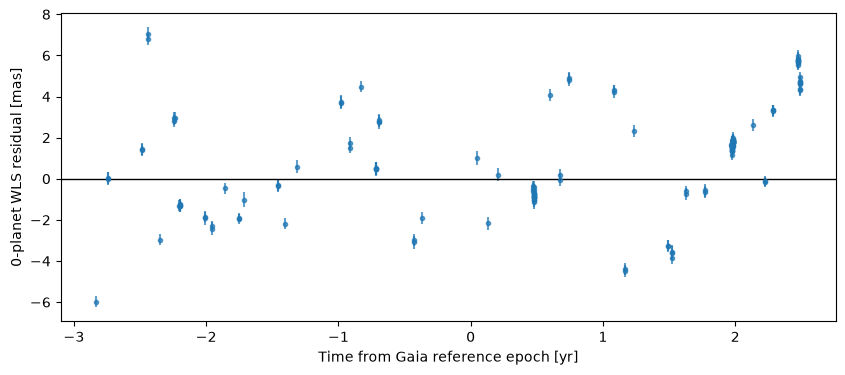

In [10]:
def astrometric_design_matrix(t, scan_angle, pf):
    return np.column_stack([
        np.sin(scan_angle), np.cos(scan_angle),
        np.sin(scan_angle) * t, np.cos(scan_angle) * t, pf,
    ])


def weighted_linear_solution(t, scan_angle, pf, values, errors):
    X = astrometric_design_matrix(t, scan_angle, pf)
    w = 1.0 / np.square(errors)
    normal = X.T @ (w[:, None] * X)
    covariance = np.linalg.pinv(normal)
    beta = covariance @ (X.T @ (w * values))
    return beta, covariance, X


beta_wls, beta_cov, X = weighted_linear_solution(
    t_years, psi, parallax_factor, y, yerr
)
beta_names = ["alpha0_mas", "delta0_mas", "pmra_mas_yr", "pmdec_mas_yr", "parallax_mas"]
beta_floor = np.array([10.0, 10.0, 10.0, 10.0, 5.0])
beta_prior_scale = np.maximum(10.0 * np.sqrt(np.diag(beta_cov)), beta_floor)

display(pd.DataFrame({"parameter": beta_names, "WLS": beta_wls, "prior_scale": beta_prior_scale}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(t_years, y - X @ beta_wls, yerr=yerr, fmt=".", alpha=0.7)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="Time from Gaia reference epoch [yr]", ylabel="0-planet WLS residual [mas]")
plt.show()

In [11]:
def stellar_reflex_al(t, scan_angle, parallax_mas, planets, mstar=MSTAR, rstar=RSTAR):
    """JAXoplanet stellar reflex projected into Gaia along-scan coordinates."""
    t_days = jnp.asarray(t) * 365.25
    system = System(Central(mass=jnp.asarray(mstar), radius=jnp.asarray(rstar)))

    for planet in planets:
        period_days = planet["period_years"] * 365.25
        mean_motion = 2.0 * jnp.pi / period_days
        system = system.add_body(
            period=period_days, mass=planet["mass_msun"],
            eccentricity=planet["eccentricity"], inclination=planet["inclination"],
            omega_peri=planet["omega"], asc_node=planet["Omega"],
            time_peri=-planet["M0"] / mean_motion,
        )

    x_rsun = jnp.zeros_like(t_days)
    y_rsun = jnp.zeros_like(t_days)
    for body in system.bodies:
        x_body, y_body, _ = body.central_position(t_days)
        x_rsun = x_rsun + x_body
        y_rsun = y_rsun + y_body

    x_mas = x_rsun * RSUN_TO_AU * parallax_mas
    y_mas = y_rsun * RSUN_TO_AU * parallax_mas
    return x_mas * jnp.cos(scan_angle) + y_mas * jnp.sin(scan_angle)


def build_astrometric_model(n_planets, beta_loc, beta_scale):
    log_period_min = np.log(PERIOD_MIN_YEARS)
    log_period_max = np.log(PERIOD_MAX_YEARS)
    log_mass_min = np.log(MARS_TO_MSUN)
    log_mass_max = np.log(MAX_COMPANION_MASS_MSUN)

    def model(t, scan_angle, pf, reported_error, observed=None):
        beta = numpyro.sample(
            "astrometric_params",
            dist.Normal(jnp.asarray(beta_loc), jnp.asarray(beta_scale)).to_event(1),
        )
        noise_scale = numpyro.sample("noise_scale", dist.LogNormal(0.0, 0.7))

        period_logs = []
        if n_planets >= 1:
            log_period_1 = numpyro.sample("log_period_1", dist.Uniform(log_period_min, log_period_max))
            period_logs.append(log_period_1)
        if n_planets == 2:
            log_period_2 = numpyro.sample("log_period_2", dist.Uniform(log_period_min, log_period_max))
            # Both periods are sampled independently over the full range, then sorted
            # so planet 1 = inner / planet 2 = outer. This only fixes a label (the
            # planets are otherwise exchangeable); sampling P2 conditional on P1 as a
            # fraction of the remaining range instead would force P2 >= P1 by
            # construction and bias it toward the prior's upper edge (not a flat
            # order-statistic prior).
            period_logs = list(jnp.sort(jnp.stack([log_period_1, log_period_2])))

        planets = []
        for idx in range(1, n_planets + 1):
            log_mass = numpyro.sample(
                f"log_mass_{idx}", dist.Uniform(log_mass_min, log_mass_max)
            )
            eccentricity = numpyro.sample(
                f"eccentricity_{idx}", dist.Uniform(0.0, 0.99)
            )
            cos_i = numpyro.sample(f"cos_i_{idx}", dist.Uniform(-1.0, 1.0))
            omega = numpyro.sample(f"omega_{idx}", dist.Uniform(0.0, 2.0 * jnp.pi))
            Omega = numpyro.sample(f"Omega_{idx}", dist.Uniform(0.0, 2.0 * jnp.pi))
            M0 = numpyro.sample(f"M0_{idx}", dist.Uniform(0.0, 2.0 * jnp.pi))
            period_years = jnp.exp(period_logs[idx - 1])
            mass_msun = jnp.exp(log_mass)
            numpyro.deterministic(f"period_years_{idx}", period_years)
            numpyro.deterministic(f"mass_mjup_{idx}", mass_msun / MJUP_TO_MSUN)
            planets.append({
                "period_years": period_years, "mass_msun": mass_msun,
                "eccentricity": eccentricity, "inclination": jnp.arccos(cos_i),
                "omega": omega, "Omega": Omega, "M0": M0,
            })

        sin_psi, cos_psi = jnp.sin(scan_angle), jnp.cos(scan_angle)
        astrometry = (
            sin_psi * beta[0] + cos_psi * beta[1]
            + sin_psi * beta[2] * t + cos_psi * beta[3] * t + beta[4] * pf
        )
        reflex = stellar_reflex_al(t, scan_angle, beta[4], planets)
        mu = numpyro.deterministic("mu", astrometry + reflex)
        sigma = reported_error * noise_scale
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=observed)

    return model


In [12]:
def injected_planets(truth_row):
    if truth_row is None:
        return []
    planets = []
    for idx in range(1, int(truth_row["n_planets"]) + 1):
        mass_msun = float(truth_row[f"Mp_{idx}_msun"])
        a_au = float(truth_row[f"a_{idx}_au"])
        planets.append({
            "period_years": np.sqrt(a_au**3 / (MSTAR + mass_msun)),
            "mass_msun": mass_msun, "eccentricity": float(truth_row[f"e_{idx}"]),
            "cos_i": np.cos(float(truth_row[f"i_{idx}_rad"])),
            "Omega": float(truth_row[f"Omega_{idx}_rad"]) % (2 * np.pi),
            "omega": float(truth_row[f"omega_{idx}_rad"]) % (2 * np.pi),
            "M0": float(truth_row[f"M0_{idx}_rad"]) % (2 * np.pi),
        })
    return sorted(planets, key=lambda p: p["period_years"])


def make_initial_values(n_planets, use_truth=USE_INJECTED_INIT):
    values = {"astrometric_params": jnp.asarray(beta_wls), "noise_scale": 1.0}
    injected = injected_planets(truth) if use_truth else []
    defaults = [
        {"period_years": 2.0, "mass_msun": MJUP_TO_MSUN, "eccentricity": 0.2,
         "cos_i": 0.0, "Omega": 1.0, "omega": 2.0, "M0": 0.5},
        {"period_years": 8.0, "mass_msun": MJUP_TO_MSUN, "eccentricity": 0.2,
         "cos_i": 0.0, "Omega": 2.0, "omega": 1.0, "M0": 1.5},
    ]
    starts = sorted((injected + defaults[len(injected):])[:n_planets], key=lambda p: p["period_years"])
    log_period_min, log_period_max = np.log(PERIOD_MIN_YEARS), np.log(PERIOD_MAX_YEARS)
    for idx, planet in enumerate(starts, start=1):
        if n_planets and idx <= 2:
            values[f"log_period_{idx}"] = np.clip(
                np.log(planet["period_years"]), log_period_min + 1e-4, log_period_max - 1e-4
            )
        values[f"log_mass_{idx}"] = np.clip(
            np.log(planet["mass_msun"]), np.log(MARS_TO_MSUN) + 1e-4,
            np.log(MAX_COMPANION_MASS_MSUN) - 1e-4,
        )
        values[f"eccentricity_{idx}"] = np.clip(planet["eccentricity"], 1e-4, 0.9899)
        values[f"cos_i_{idx}"] = np.clip(planet["cos_i"], -0.9999, 0.9999)
        for angle in ["Omega", "omega", "M0"]:
            values[f"{angle}_{idx}"] = np.clip(planet[angle] % (2 * np.pi), 1e-4, 2 * np.pi - 1e-4)
    return values


def fit_model(n_planets, rng_key, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES):
    model = build_astrometric_model(n_planets, beta_wls, beta_prior_scale)
    init_values = make_initial_values(n_planets)
    kernel = NUTS(
        model, init_strategy=init_to_value(values=init_values),
        target_accept_prob=TARGET_ACCEPT, dense_mass=True,
    )
    sampler = MCMC(
        kernel, num_warmup=num_warmup, num_samples=num_samples,
        num_chains=NUM_CHAINS, chain_method="sequential", progress_bar=True,
    )
    sampler.run(
        rng_key, jnp.asarray(t_years), jnp.asarray(psi), jnp.asarray(parallax_factor),
        jnp.asarray(yerr), observed=jnp.asarray(y),
        extra_fields=("potential_energy",),
    )
    return {"model": model, "sampler": sampler, "samples": sampler.get_samples()}


## Run the three MCMC fits

The first run for each model includes JAX compilation. A two-planet astrometric posterior can be strongly multimodal; truth initialization tests local recovery, not whether a blind search finds the correct mode.

In [13]:
fits = {}
keys = jax.random.split(jax.random.key(RNG_SEED), len(MODEL_ORDERS))
for order, key in zip(MODEL_ORDERS, keys):
    print("\n" + "=" * 72)
    print(f"Fitting {order}-planet model to {dataset['system_id']}")
    print("=" * 72)
    fits[order] = fit_model(order, key)
    fits[order]["sampler"].print_summary(exclude_deterministic=False)


Fitting 0-planet model to 2planet_snrfilter_SYS_0007728


sample: 100%|██████████| 1000/1000 [00:00<00:00, 3775.05it/s, 7 steps of size 6.32e-01. acc. prob=0.92]



                           mean       std    median      5.0%     95.0%     n_eff     r_hat
astrometric_params[0]      1.35      0.44      1.35      0.60      2.00   1542.15      1.00
astrometric_params[1]     -1.69      0.35     -1.68     -2.22     -1.14   1773.15      1.00
astrometric_params[2]    108.82      0.26    108.82    108.40    109.26   1799.88      1.00
astrometric_params[3]    -38.71      0.19    -38.71    -39.04    -38.42   1885.30      1.00
astrometric_params[4]     20.84      0.60     20.82     19.84     21.79   1350.39      1.00
                mu[0]     -1.81      0.90     -1.78     -3.16     -0.27   1578.23      1.00
                mu[1]   -170.82      0.77   -170.81   -172.18   -169.58   1947.23      1.00
                mu[2]   -168.99      0.77   -168.97   -170.35   -167.75   1941.72      1.00
                mu[3]    184.94      0.71    184.93    183.64    185.99   1990.68      1.00
                mu[4]    184.05      0.71    184.03    182.74    185.10   1991.

sample: 100%|██████████| 1000/1000 [00:02<00:00, 442.89it/s, 31 steps of size 1.79e-01. acc. prob=0.87]



                           mean       std    median      5.0%     95.0%     n_eff     r_hat
                 M0_1      6.27      0.02      6.27      6.24      6.28    473.94      1.01
              Omega_1      1.28      0.18      1.26      1.04      1.61     65.69      1.04
astrometric_params[0]      5.68      0.82      5.60      4.42      7.01     58.02      1.06
astrometric_params[1]      1.89      0.48      1.85      1.06      2.62     68.45      1.04
astrometric_params[2]    107.92      0.11    107.92    107.73    108.09    777.71      1.00
astrometric_params[3]    -38.84      0.08    -38.84    -38.96    -38.69    166.32      1.02
astrometric_params[4]     20.42      0.23     20.42     20.07     20.80    308.70      1.01
              cos_i_1     -0.64      0.05     -0.64     -0.72     -0.57    456.63      1.01
       eccentricity_1      0.73      0.09      0.72      0.61      0.89     56.85      1.05
           log_mass_1     -2.81      0.11     -2.83     -2.97     -2.62     50.

sample: 100%|██████████| 1000/1000 [00:39<00:00, 25.53it/s, 1023 steps of size 4.55e-03. acc. prob=0.88]


                           mean       std    median      5.0%     95.0%     n_eff     r_hat
                 M0_1      5.70      0.46      5.79      5.13      6.28     61.59      1.04
                 M0_2      0.82      0.28      0.79      0.38      1.27     16.16      1.07
              Omega_1      2.51      0.04      2.50      2.45      2.57     29.80      1.05
              Omega_2      2.54      0.06      2.54      2.44      2.63     11.93      1.07
astrometric_params[0]     -1.27      1.02     -1.55     -2.82      0.29      8.30      1.16
astrometric_params[1]      2.42      1.24      2.29      0.53      4.40     28.31      1.06
astrometric_params[2]    104.56      0.54    104.62    103.68    105.39     30.14      1.04
astrometric_params[3]    -33.46      1.32    -33.71    -35.46    -31.57     25.60      1.06
astrometric_params[4]     20.19      0.03     20.19     20.15     20.24    484.99      1.01
              cos_i_1     -0.67      0.02     -0.66     -0.69     -0.64     87.

,n_planets,WAIC,p_WAIC,divergences,delta_WAIC
2,2,-238.811908,15.143377,37,0.000000
1,1,445.773254,27.399213,1,684.585162
0,0,753.848880,6.813616,0,992.660788


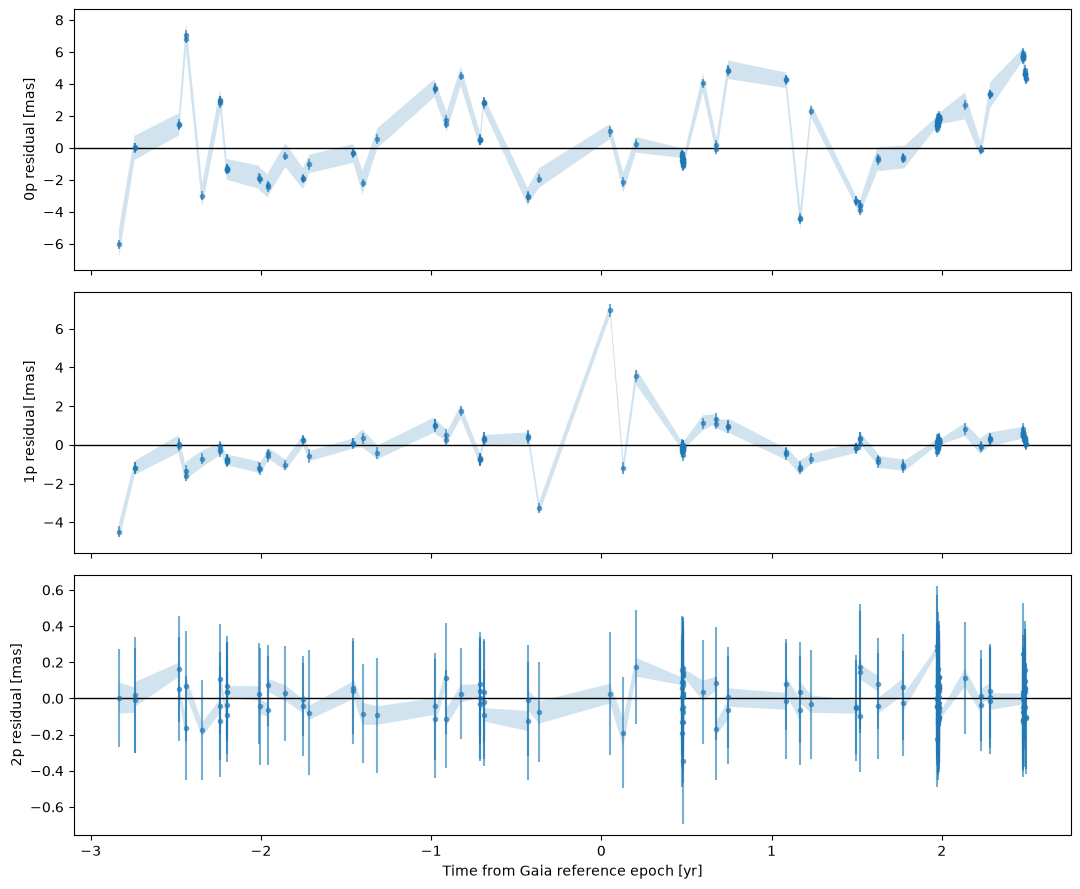

In [14]:
def compute_waic(fit):
    ll = np.asarray(log_likelihood(
        fit["model"], fit["samples"],
        jnp.asarray(t_years), jnp.asarray(psi), jnp.asarray(parallax_factor),
        jnp.asarray(yerr), observed=jnp.asarray(y),
    )["obs"])
    lppd = np.sum(logsumexp(jnp.asarray(ll), axis=0) - np.log(ll.shape[0]))
    p_waic = np.sum(np.var(ll, axis=0, ddof=1))
    return float(-2.0 * (lppd - p_waic)), float(p_waic)


comparison = []
for order, fit in fits.items():
    waic, p_waic = compute_waic(fit)
    divergent = int(np.asarray(fit["sampler"].get_extra_fields()["diverging"]).sum())
    comparison.append({"n_planets": order, "WAIC": waic, "p_WAIC": p_waic, "divergences": divergent})
comparison = pd.DataFrame(comparison).sort_values("WAIC")
comparison["delta_WAIC"] = comparison["WAIC"] - comparison["WAIC"].min()
display(comparison)

fig, axes = plt.subplots(len(fits), 1, figsize=(11, 3 * len(fits)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (order, fit) in zip(axes, fits.items()):
    predictive = Predictive(fit["model"], posterior_samples=fit["samples"], return_sites=["mu"])
    mu = np.asarray(predictive(
        jax.random.key(100 + order), jnp.asarray(t_years), jnp.asarray(psi),
        jnp.asarray(parallax_factor), jnp.asarray(yerr), observed=None,
    )["mu"])
    median = np.median(mu, axis=0)
    lo, hi = np.percentile(mu, [16, 84], axis=0)
    ax.errorbar(t_years, y - median, yerr=yerr, fmt=".", alpha=0.6)
    ax.fill_between(t_years, y - hi, y - lo, alpha=0.2)
    ax.axhline(0, color="k", lw=1)
    ax.set_ylabel(f"{order}p residual [mas]")
axes[-1].set_xlabel("Time from Gaia reference epoch [yr]")
plt.tight_layout()
plt.show()

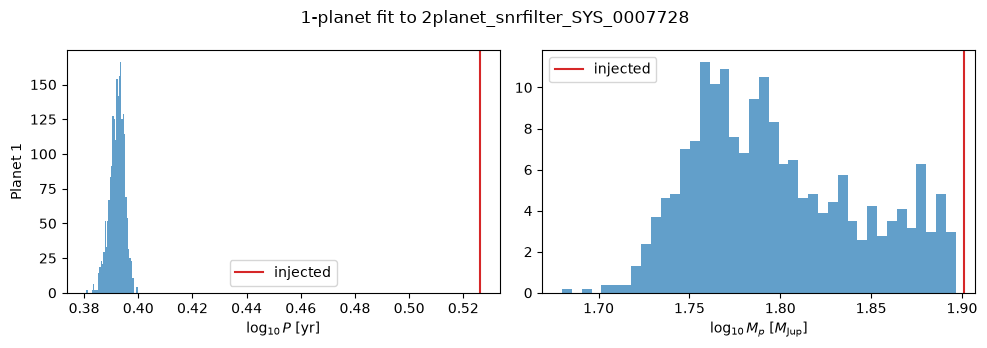

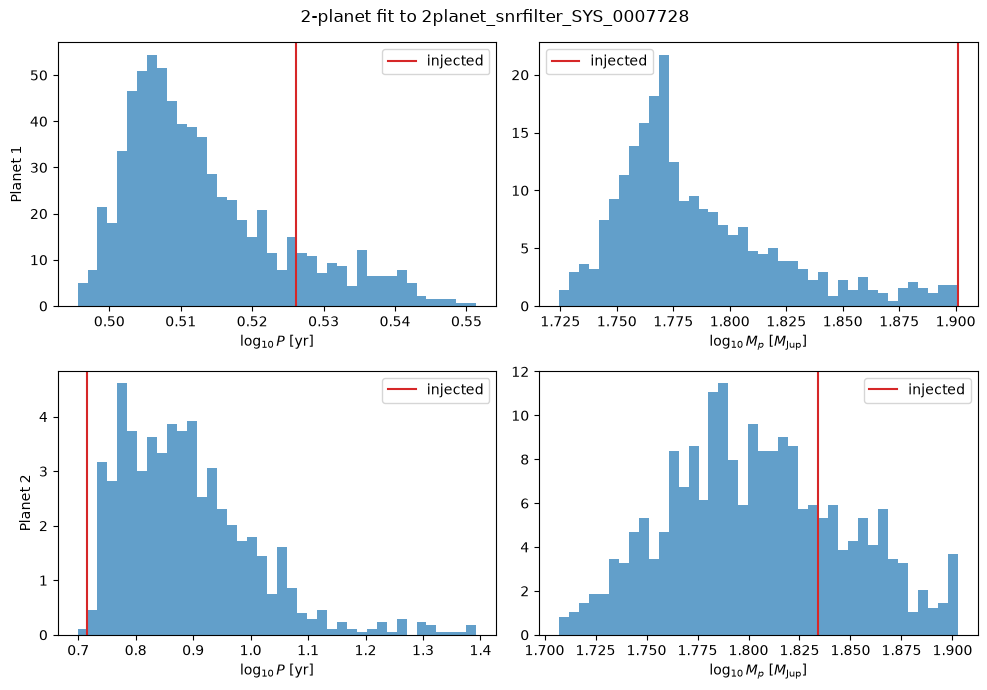

In [15]:
injected = injected_planets(truth)
for order in [o for o in MODEL_ORDERS if o > 0]:
    samples = fits[order]["samples"]
    fig, axes = plt.subplots(order, 2, figsize=(10, 3.5 * order), squeeze=False)
    for idx in range(1, order + 1):
        period_samples = np.asarray(samples[f"period_years_{idx}"])
        mass_samples = np.asarray(samples[f"mass_mjup_{idx}"])
        axes[idx - 1, 0].hist(np.log10(period_samples), bins=40, density=True, alpha=0.7)
        axes[idx - 1, 1].hist(np.log10(mass_samples), bins=40, density=True, alpha=0.7)
        if idx <= len(injected):
            axes[idx - 1, 0].axvline(np.log10(injected[idx - 1]["period_years"]), color="C3", label="injected")
            axes[idx - 1, 1].axvline(np.log10(injected[idx - 1]["mass_msun"] / MJUP_TO_MSUN), color="C3", label="injected")
            axes[idx - 1, 0].legend()
            axes[idx - 1, 1].legend()
        axes[idx - 1, 0].set_ylabel(f"Planet {idx}")
        axes[idx - 1, 0].set_xlabel(r"$\log_{10} P$ [yr]")
        axes[idx - 1, 1].set_xlabel(r"$\log_{10} M_p$ [$M_{\rm Jup}$]")
    fig.suptitle(f"{order}-planet fit to {dataset['system_id']}")
    plt.tight_layout()
    plt.show()

## Interpretation checklist

- Require multiple chains with $\hat R \approx 1$, adequate effective sample sizes, and few/no divergences before interpreting a fit.
- A truth-seeded run only tests whether the injected local mode is recoverable. Set `USE_INJECTED_INIT=False` and try several seeds for a blind-search test.
- Periods much longer than the observing baseline will be weakly identified and covariant with proper motion/acceleration.
- WAIC is a convenience diagnostic here, not a substitute for injection-recovery calibration or a carefully validated model-evidence calculation.
- The fitted `noise_scale` is expected to differ from one because the HDF5 epoch table reports a different uncertainty construction from the one used to inject scatter.